# **Exploratory Analysis for Q1 & Q2**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving challenge_basic.py to challenge_basic.py
Saving cleaned_data_combined_modified.csv to cleaned_data_combined_modified.csv
Saving cleaned_data_combined.csv to cleaned_data_combined.csv
Saving data_cleaning.py to data_cleaning.py
Saving example_pred.py to example_pred.py


In [8]:
from data_cleaning import parse_q2_response, word_bank_by_label

In [11]:
df = pd.read_csv("cleaned_data_combined_modified.csv")
df.head()  # Check the first few rows to confirm everything loaded correctly.

,id,"Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)",Q2: How many ingredients would you expect this food item to contain?,Q3: In what setting would you expect this food to be served? Please check all that apply,Q4: How much would you expect to pay for one serving of this food item?,Q5: What movie do you think of when thinking of this food item?,Q6: What drink would you pair with this food item?,"Q7: When you think about this food item, who does it remind you of?",Q8: How much hot sauce would you add to this food item?,Label
0,716549,3,6,"Week day lunch,At a party,Late night snack",5,Cloudy with a Chance of Meatballs,Coke,Friends,A little (mild),Pizza
1,715742,4,"bread, meet","Week day lunch,At a party,Late night snack",5$ for a large piece,All sort of american young boy movies,Coke,"Friends,Teachers,Strangers",NaN,Pizza
2,727333,3,5,"Week day lunch,Week day dinner,Weekend lunch,W...",10dollar,action movie,cola,Friends,A moderate amount (medium),Pizza
3,606874,4,6-7,"Week day lunch,Week day dinner,Weekend lunch,W...",$3,Mamma Mia,Soda,"Siblings,Friends,Teachers",I will have some of this food item with my hot...,Pizza
4,505318,2,3 or more,"Week day lunch,Week day dinner,Weekend lunch,W...",$5,Cloudy with a chance of meatballs,Soda,"Siblings,Friends",A little (mild),Pizza


In [12]:
q2_col = "Q2: How many ingredients would you expect this food item to contain?"
def clean_q2_row(row):
    bank = word_bank_by_label.get(row["Label"], None)
    return parse_q2_response(row[q2_col], word_bank=bank)

df["Q2_cleaned"] = df.apply(clean_q2_row, axis=1)
df[[q2_col, "Q2_cleaned", "Label"]].head()

,Q2: How many ingredients would you expect this food item to contain?,Q2_cleaned,Label
0,6,6.0,Pizza
1,"bread, meet",NaN,Pizza
2,5,5.0,Pizza
3,6-7,6.5,Pizza
4,3 or more,3.0,Pizza


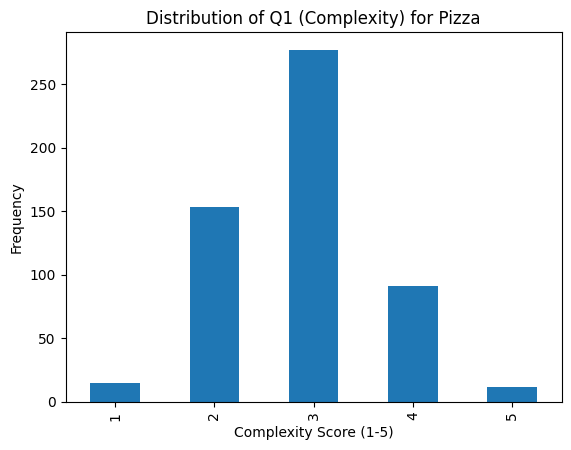

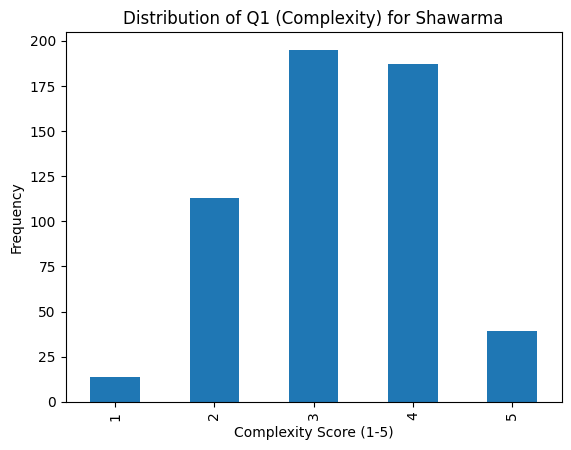

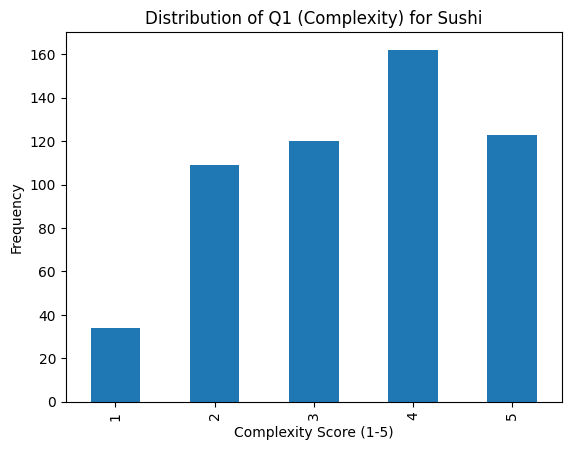

In [17]:
%matplotlib inline

labels = df["Label"].unique()

for lab in labels:
    subset = df[df["Label"] == lab]
    plt.figure()
    subset["Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)"].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Distribution of Q1 (Complexity) for {lab}")
    plt.xlabel("Complexity Score (1-5)")
    plt.ylabel("Frequency")
    plt.show()

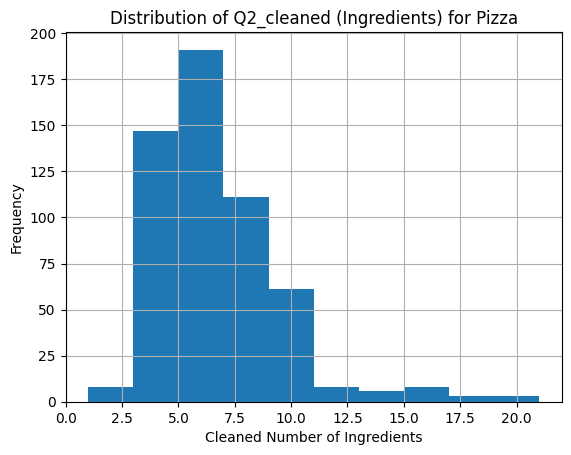

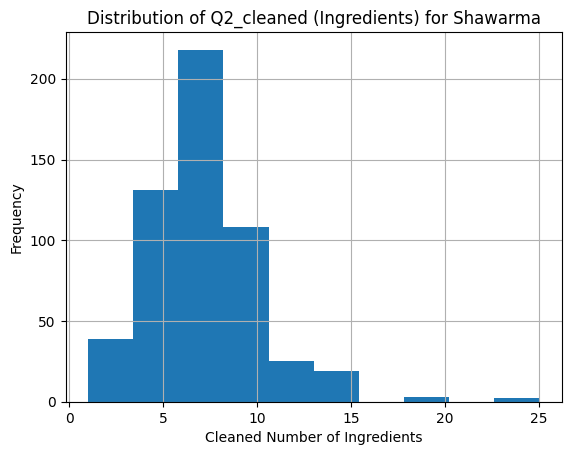

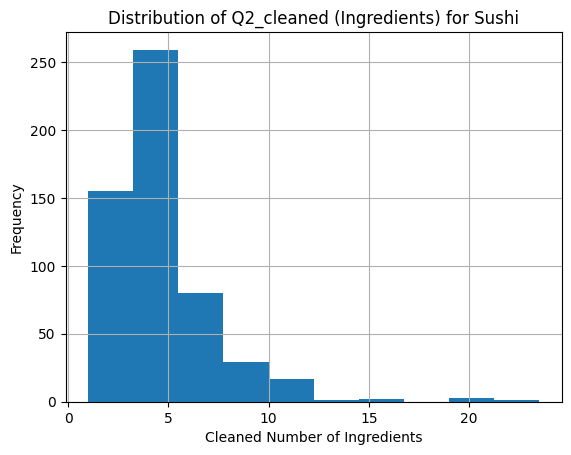

In [18]:
for lab in labels:
    subset = df[df["Label"] == lab]
    plt.figure()
    subset["Q2_cleaned"].hist(bins=10)  # adjust bin size as needed
    plt.title(f"Distribution of Q2_cleaned (Ingredients) for {lab}")
    plt.xlabel("Cleaned Number of Ingredients")
    plt.ylabel("Frequency")
    plt.show()

Overall correlation between Q1 and Q2_cleaned: 0.10563405443412124


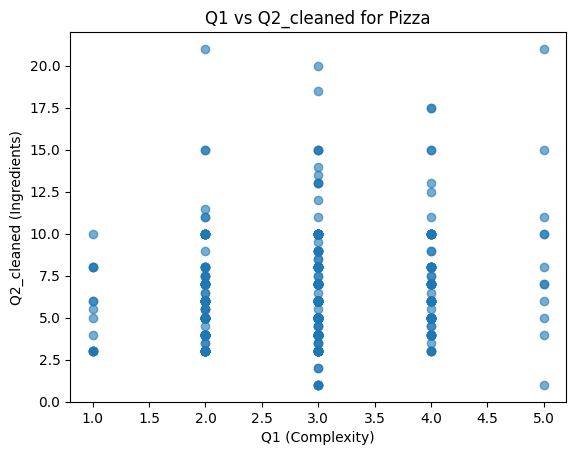

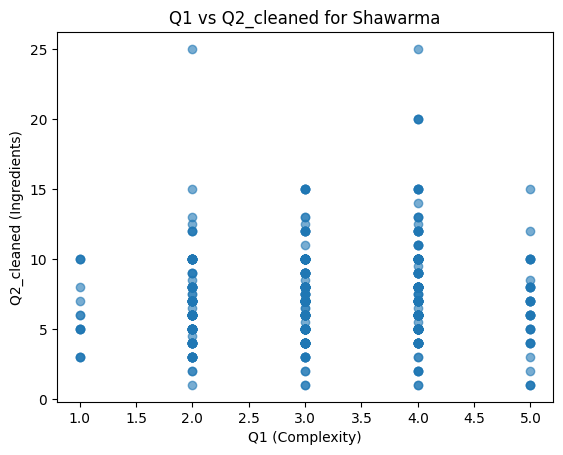

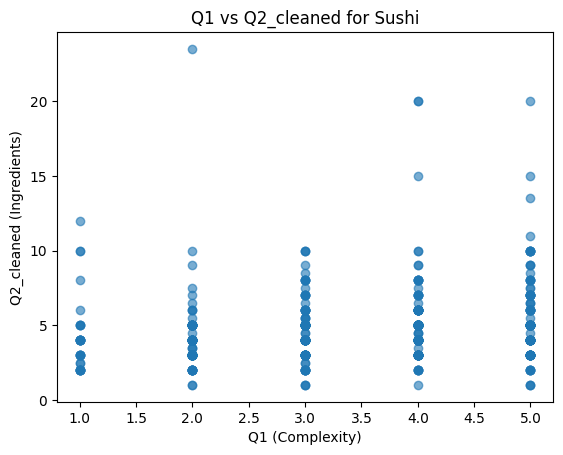

In [20]:
# Overall correlation:
overall_corr = df["Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)"].corr(df["Q2_cleaned"])
print("Overall correlation between Q1 and Q2_cleaned:", overall_corr)

# Scatter plot per label:
for lab in labels:
    subset = df[df["Label"] == lab]
    plt.figure()
    plt.scatter(subset["Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)"], subset["Q2_cleaned"], alpha=0.6)
    plt.title(f"Q1 vs Q2_cleaned for {lab}")
    plt.xlabel("Q1 (Complexity)")
    plt.ylabel("Q2_cleaned (Ingredients)")
    plt.show()


In [21]:
corr = subset["Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)"].corr(subset["Q2_cleaned"])
print("Correlation:", corr)

Correlation: 0.20884421544517118


If it’s close to 0, that supports the idea of no strong linear relationship.